## MEYER STOCK PRICE PREDICTION

In [1]:
## to change the name across the code
## ctrl + h will open the tab the fill the new name in replace
## to change the name across the entire code so you dont have to click enter everytime
## ctrl + shift + h

import pandas as pd

meyer=pd.read_csv('../stock_data/meyer.csv') ## so it can be small letter. This is cool.
meyer=meyer.drop(columns=['high_price','low_price'])
meyer.rename(columns={'trade_date':'date'},inplace=True)
meyer['date']=pd.to_datetime(meyer['date'])
meyer['month']=meyer['date'].dt.month
meyer['quarter']=meyer['date'].dt.quarter
meyer['year']=meyer['date'].dt.year

meyer

,id,symbol,date,open_price,close_price,volume,created_at,month,quarter,year
0,42843,MEYER,2017-01-03,0.87,0.87,0,2026-04-08T02:41:25.765521+00:00,1,1,2017
1,43403,MEYER,2017-01-04,0.87,0.87,0,2026-04-08T02:42:20.164398+00:00,1,1,2017
2,43513,MEYER,2017-01-05,0.87,0.87,0,2026-04-08T02:42:22.380516+00:00,1,1,2017
3,43623,MEYER,2017-01-06,0.87,0.87,5951,2026-04-08T02:42:23.84796+00:00,1,1,2017
4,43713,MEYER,2017-01-09,0.87,0.87,0,2026-04-08T02:42:26.938159+00:00,1,1,2017
...,...,...,...,...,...,...,...,...,...,...
2258,298094,MEYER,2026-07-13,18.55,18.55,23038,2026-07-13T15:10:02.995074+00:00,7,3,2026
2259,298532,MEYER,2026-07-14,18.55,18.55,83472,2026-07-14T15:10:03.094441+00:00,7,3,2026
2260,298970,MEYER,2026-07-15,18.55,18.55,11423,2026-07-15T15:10:03.078609+00:00,7,3,2026
2261,299408,MEYER,2026-07-16,18.55,18.55,14447,2026-07-16T15:10:03.113936+00:00,7,3,2026


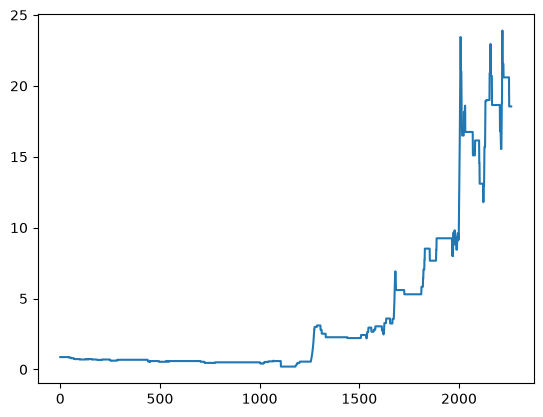

In [2]:
import matplotlib.pyplot as plt

plt.plot(meyer['close_price'])
plt.show()

In [3]:
meyer_end_month_df = (
    meyer
    .sort_values("date")
    .groupby(meyer["date"].dt.to_period("M"))
    .tail(1)
    .reset_index(drop=True)
)

meyer_end_month_df

,id,symbol,date,open_price,close_price,volume,created_at,month,quarter,year
0,45413,MEYER,2017-01-31,0.87,0.87,1000,2026-04-08T02:43:03.07753+00:00,1,1,2017
1,47235,MEYER,2017-02-28,0.87,0.87,0,2026-04-08T02:44:45.006295+00:00,2,1,2017
2,49351,MEYER,2017-03-31,0.79,0.79,699,2026-04-08T02:45:42.281198+00:00,3,1,2017
3,51178,MEYER,2017-04-28,0.73,0.73,0,2026-04-08T02:51:55.619599+00:00,4,2,2017
4,53101,MEYER,2017-05-31,0.70,0.70,0,2026-04-08T02:52:57.421655+00:00,5,2,2017
...,...,...,...,...,...,...,...,...,...,...
110,35331,MEYER,2026-03-31,18.65,18.65,28976,2026-03-31T15:00:02.085058+00:00,3,1,2026
111,281157,MEYER,2026-04-30,16.00,16.00,520403,2026-04-30T15:00:02.170664+00:00,4,2,2026
112,284223,MEYER,2026-05-29,20.60,20.60,34834,2026-05-29T15:00:02.455558+00:00,5,2,2026
113,294151,MEYER,2026-06-30,20.60,20.60,21848,2026-06-30T15:10:03.08168+00:00,6,2,2026


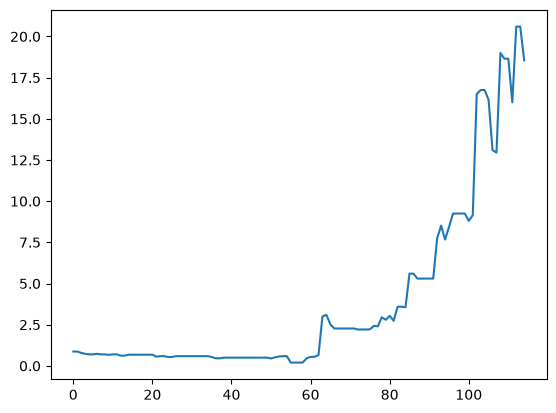

In [4]:
plt.plot(meyer_end_month_df['close_price'])
plt.show()

In [5]:
meyer_end_month_df['returns']=meyer_end_month_df['close_price'].pct_change()*100
meyer_end_month_df

,id,symbol,date,open_price,close_price,volume,created_at,month,quarter,year,returns
0,45413,MEYER,2017-01-31,0.87,0.87,1000,2026-04-08T02:43:03.07753+00:00,1,1,2017,NaN
1,47235,MEYER,2017-02-28,0.87,0.87,0,2026-04-08T02:44:45.006295+00:00,2,1,2017,0.000000
2,49351,MEYER,2017-03-31,0.79,0.79,699,2026-04-08T02:45:42.281198+00:00,3,1,2017,-9.195402
3,51178,MEYER,2017-04-28,0.73,0.73,0,2026-04-08T02:51:55.619599+00:00,4,2,2017,-7.594937
4,53101,MEYER,2017-05-31,0.70,0.70,0,2026-04-08T02:52:57.421655+00:00,5,2,2017,-4.109589
...,...,...,...,...,...,...,...,...,...,...,...
110,35331,MEYER,2026-03-31,18.65,18.65,28976,2026-03-31T15:00:02.085058+00:00,3,1,2026,0.000000
111,281157,MEYER,2026-04-30,16.00,16.00,520403,2026-04-30T15:00:02.170664+00:00,4,2,2026,-14.209115
112,284223,MEYER,2026-05-29,20.60,20.60,34834,2026-05-29T15:00:02.455558+00:00,5,2,2026,28.750000
113,294151,MEYER,2026-06-30,20.60,20.60,21848,2026-06-30T15:10:03.08168+00:00,6,2,2026,0.000000


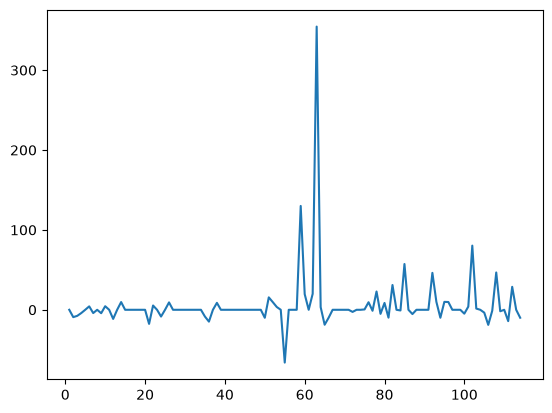

In [6]:
plt.plot(meyer_end_month_df['returns'])
plt.show()

In [7]:
## Test stationarity

from statsmodels.tsa.stattools import adfuller

result = adfuller(meyer_end_month_df['returns'].dropna())
print(result)
pvalue = result[1]
if pvalue < 0.05:
    print('stationary')
else:
    print('not stationary')

(np.float64(-10.112175248675783), np.float64(9.936881855020803e-18), 0, 113, {'1%': np.float64(-3.489589552580676), '5%': np.float64(-2.887477210140433), '10%': np.float64(-2.580604145195395)}, np.float64(1026.9272204001877))
stationary


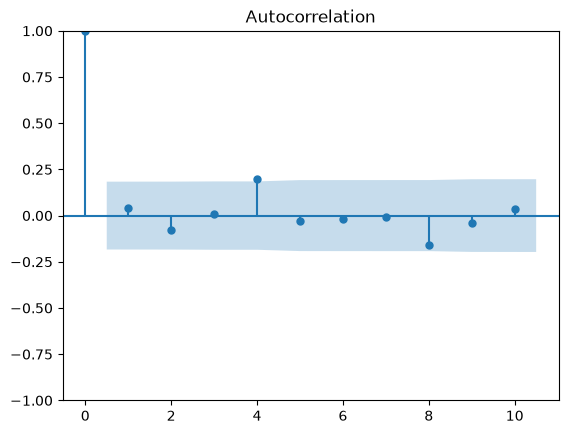

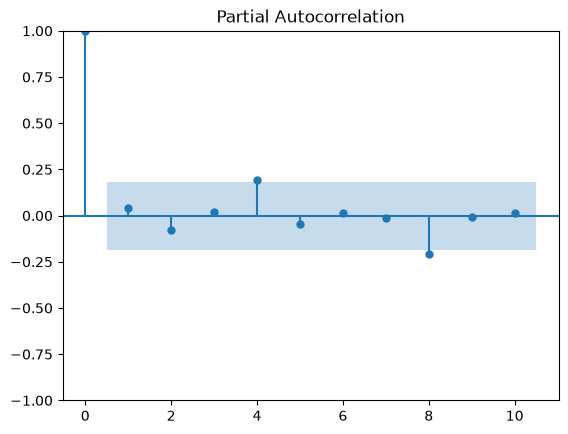

In [8]:
# Plotting the autocorrelation function and the partial autocorrelation function
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
plot_acf(meyer_end_month_df['returns'].dropna(), lags=10)
plot_pacf(meyer_end_month_df['returns'].dropna(), lags=10)
plt.show()

In [9]:
import random
random.seed(12345)

from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
import numpy as np
import warnings

warnings.filterwarnings('ignore')

train=meyer_end_month_df['close_price'][:-10]
test=meyer_end_month_df['close_price'][-10:]

# Grid Search on the SARIMA model
import numpy as np
scores = []
for p in range(3):
    for i in range(3):
        for q in range(3):
            for P in range(3):
                for D in range(3):
                    for Q in range(3):
                        try:
                            mod = SARIMAX(train, 
                            order=(p,i,q), seasonal_order=(P,D,Q,12))
                            res = mod.fit(disp=False)
                            fcst=res.forecast(steps=10)
                            score =  [p,i,q,P,D,Q,r2_score(test,fcst)]
                            print(score)
                            scores.append(score)
                            del mod
                            del res
                        except:
                            print('errored')


[0, 0, 0, 0, 0, 0, -43.81631401410609]
[0, 0, 0, 0, 0, 1, -19.790569806363163]
[0, 0, 0, 0, 0, 2, -11.762492211664862]
[0, 0, 0, 0, 1, 0, -9.101877085700883]
[0, 0, 0, 0, 1, 1, -6.015166102989258]
[0, 0, 0, 0, 1, 2, -4.979148823380305]
[0, 0, 0, 0, 2, 0, -3.418254956092132]
[0, 0, 0, 0, 2, 1, -3.3651229917782404]
[0, 0, 0, 0, 2, 2, -2.9384929413799776]
[0, 0, 0, 1, 0, 0, -10.897105954208675]
[0, 0, 0, 1, 0, 1, -7.3911181423734575]
[0, 0, 0, 1, 0, 2, -6.535960128448436]
[0, 0, 0, 1, 1, 0, -4.0444544519551044]
[0, 0, 0, 1, 1, 1, -4.03683474076141]
[0, 0, 0, 1, 1, 2, -3.823196418813107]
[0, 0, 0, 1, 2, 0, -3.334857428701768]
[0, 0, 0, 1, 2, 1, -3.285703360036525]
[0, 0, 0, 1, 2, 2, -2.7756949130739215]
[0, 0, 0, 2, 0, 0, -5.657820007070407]
[0, 0, 0, 2, 0, 1, -5.6578869304893376]
[0, 0, 0, 2, 0, 2, -5.621360495881819]
[0, 0, 0, 2, 1, 0, -4.0208463216265935]
[0, 0, 0, 2, 1, 1, -4.004843332650445]
[0, 0, 0, 2, 1, 2, -4.170077710302516]
[0, 0, 0, 2, 2, 0, -3.0716369649533153]
[0, 0, 0, 2, 2,

In [10]:
res = pd.DataFrame(scores)
res.columns = ['p', 'i', 'q', 'P', 'D', 'Q', 'score']
result = res.sort_values('score')
result

,p,i,q,P,D,Q,score
563,2,0,2,2,1,2,-897.314232
168,0,2,0,0,2,0,-111.156731
411,1,2,0,0,2,0,-63.947456
177,0,2,0,1,2,0,-51.702841
0,0,0,0,0,0,0,-43.816314
...,...,...,...,...,...,...,...
173,0,2,0,1,0,2,0.219461
164,0,2,0,0,0,2,0.223043
182,0,2,0,2,0,2,0.226524
181,0,2,0,2,0,1,0.226564


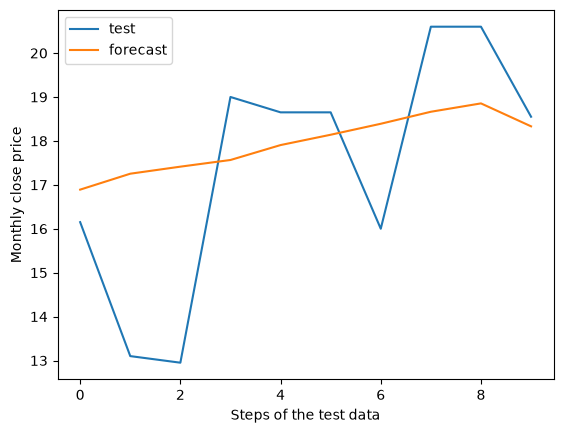

r2_score:  0.23300207135979978
rmse:  2.3054301163239255
description:  count    115.000000
mean       3.857826
std        5.443000
min        0.200000
25%        0.590000
50%        0.700000
75%        5.300000
max       20.600000
Name: close_price, dtype: float64


In [11]:
# Fitting a SARIMAX model with our best model 
# order=(2,0,1), seasonal_order=(1,2,1,10)

import random
random.seed(12345)
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import numpy as np
import warnings

warnings.filterwarnings('ignore')

y_train=meyer_end_month_df['close_price'][:-10]
y_test=meyer_end_month_df['close_price'][-10:]

# scaler=StandardScaler()
# exog_train_scaled=scaler.fit_transform(X_full[:-10])
# exog_test_scaled=scaler.transform(X_full[-10:])

mod = SARIMAX(
y_train,
order=(0,2,0), 
seasonal_order=(1,0,1,12),
)

res = mod.fit(disp=False)
fcst = res.forecast(steps=10)

plt.plot(list(y_test))
plt.plot(list(fcst))
plt.xlabel('Steps of the test data')
plt.ylabel('Monthly close price')
plt.legend(['test', 'forecast'])
plt.show()
print('r2_score: ',r2_score(y_test, fcst))
print('rmse: ', np.sqrt(mean_squared_error(y_test,fcst)))
print('description: ', meyer_end_month_df.close_price.describe())

Its not capturing the variations properly. Lets try the returns

In [12]:
import random
random.seed(12345)

from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
import numpy as np
import warnings

warnings.filterwarnings('ignore')

train=meyer_end_month_df['returns'].dropna()[:-10]
test=meyer_end_month_df['returns'].dropna()[-10:]

# Grid Search on the SARIMA model
import numpy as np
scores = []
for p in range(3):
    for i in range(3):
        for q in range(3):
            for P in range(3):
                for D in range(3):
                    for Q in range(3):
                        try:
                            mod = SARIMAX(train, 
                            order=(p,i,q), seasonal_order=(P,D,Q,12))
                            res = mod.fit(disp=False)
                            fcst=res.forecast(steps=10)
                            score =  [p,i,q,P,D,Q,r2_score(test,fcst)]
                            print(score)
                            scores.append(score)
                            del mod
                            del res
                        except:
                            print('errored')


[0, 0, 0, 0, 0, 0, -0.01847639897852682]
[0, 0, 0, 0, 0, 1, -0.0260801764833416]
[0, 0, 0, 0, 0, 2, -0.02439025574169995]
[0, 0, 0, 0, 1, 0, -2.111053247473873]
[0, 0, 0, 0, 1, 1, -1.0120516363395762]
[0, 0, 0, 0, 1, 2, -0.9968610445389015]
[0, 0, 0, 0, 2, 0, -9.33535656478059]
[0, 0, 0, 0, 2, 1, -2.579280486533028]
[0, 0, 0, 0, 2, 2, -1.966142731622662]
[0, 0, 0, 1, 0, 0, -0.026305769099427945]
[0, 0, 0, 1, 0, 1, -0.024162338126030747]
[0, 0, 0, 1, 0, 2, -0.024408694952197774]
[0, 0, 0, 1, 1, 0, -1.0554830473133054]
[0, 0, 0, 1, 1, 1, -0.9988963730859617]
[0, 0, 0, 1, 1, 2, -1.213725635040682]
[0, 0, 0, 1, 2, 0, -3.377198988802352]
[0, 0, 0, 1, 2, 1, -1.493613902951176]
[0, 0, 0, 1, 2, 2, -2.7820684102604063]
[0, 0, 0, 2, 0, 0, -0.024499534803119616]
[0, 0, 0, 2, 0, 1, -0.024504075109022416]
[0, 0, 0, 2, 0, 2, -0.01916535022551824]
[0, 0, 0, 2, 1, 0, -0.7720347731628214]
[0, 0, 0, 2, 1, 1, -1.1155080882789656]
[0, 0, 0, 2, 1, 2, -1.2761811638495741]
[0, 0, 0, 2, 2, 0, -11.825649767751

In [13]:
res = pd.DataFrame(scores)
res.columns = ['p', 'i', 'q', 'P', 'D', 'Q', 'score']
result = res.sort_values('score')
result

,p,i,q,P,D,Q,score
411,1,2,0,0,2,0,-1076.578021
168,0,2,0,0,2,0,-859.705242
420,1,2,0,1,2,0,-649.156593
177,0,2,0,1,2,0,-626.854024
412,1,2,0,0,2,1,-526.855921
...,...,...,...,...,...,...,...
631,2,1,2,1,0,2,0.040076
640,2,1,2,2,0,2,0.040821
639,2,1,2,2,0,1,0.047261
389,1,1,2,1,0,2,0.057121


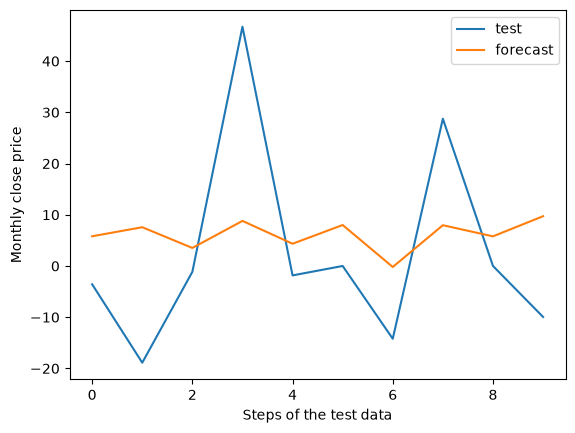

r2_score:  0.06052977239170343
rmse:  18.43495141733246
description:  count    114.000000
mean       5.967902
std       38.064284
min      -66.101695
25%        0.000000
50%        0.000000
75%        0.339367
max      354.545455
Name: returns, dtype: float64


In [14]:
# Fitting a SARIMAX model with our best model 
# order=(2,0,1), seasonal_order=(1,2,1,10)

import random
random.seed(12345)
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore')

y_train=meyer_end_month_df['returns'].dropna()[:-10]
y_test=meyer_end_month_df['returns'].dropna()[-10:]

# scaler=StandardScaler()
# exog_train_scaled=scaler.fit_transform(X_full[:-10])
# exog_test_scaled=scaler.transform(X_full[-10:])

mod = SARIMAX(
y_train,
order=(1,1,2), 
seasonal_order=(2,0,1,12),
)

res = mod.fit(disp=False)
fcst = res.forecast(steps=10)

plt.plot(list(y_test))
plt.plot(list(fcst))
plt.xlabel('Steps of the test data')
plt.ylabel('Monthly close price')
plt.legend(['test', 'forecast'])
plt.show()
print('r2_score: ',r2_score(y_test, fcst))
print('rmse: ', np.sqrt(mean_squared_error(y_test,fcst)))
print('description: ', meyer_end_month_df.returns.dropna().describe())

Very horrible. We will come back to this.
